# Real-fluid meanline design of a supersonic axial ORC turbine stage

**KCORC Summer School 2026 — TEACHER / SOLUTION NOTEBOOK**  
**Format:** short explanations alternating with hands-on Python tasks  
**Main objective:** understand and implement the essential physics of a supersonic ORC turbine design point.  
**Final extension:** generate a small fixed-geometry off-design map for the following TESPy workshop.

By the end of the tutorial you should be able to connect

$$
(p_{0,\mathrm{in}},\, T_{0,\mathrm{in}},\, p_{\mathrm{out}},\, \dot{m})
\rightarrow \Delta h_{\mathrm{is}}
\rightarrow \text{sonic throat}
\rightarrow \text{velocity triangles}
\rightarrow P,\,\eta
\rightarrow \text{basic geometry}
\rightarrow \text{off-design map}
$$

<div style="padding:0.8rem 1rem;background:#e8f5e9;border-left:6px solid #2e7d32;border-radius:5px"><b>Instructor version.</b> All student TODOs are completed. Green cells contain suggested discussion answers and teaching notes.</div>


## Workshop rhythm

| Block | Instructor input | Student work | Approx. time |
|---|---|---|---:|
| A | Real-fluid stage loading | Overall expansion and blade-speed ratio | 25 min |
| B | Choking and supersonic stator | Mach path, sonic throat, flow areas | 40 min |
| C | Impulse-stage velocity triangles | Stator/rotor triangles and Euler work | 45 min |
| D | Losses and geometry | Efficiency, partial admission, dimensions | 35 min |
| E | TESPy handoff | Small fixed-geometry map and CSV export | 20 min |

Orange cells marked **YOUR TASK** contain the equations you are expected to complete. Property calls, plotting, empirical correlations, and error handling are provided by the backend.

## 0. Environment and imports

From the repository root, the common Summer School setup is:

```bash
uv sync
```

In VS Code, select the Python interpreter from `.venv`. Run the next cell. If CoolProp or widgets are missing, the selected kernel is probably not the `uv` environment.

In [43]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kcorc_turbine import (
    CoolPropBackend,
    DesignInputs,
    design_stage,
    evaluate_rotor_offdesign,
    evaluate_stator_offdesign,
    freeze_geometry,
    inlet_temperature_for_pressure,
)
from kcorc_turbine.checks import checkpoint, compare_with_reference
from kcorc_turbine.correlations import (
    disk_friction_loss_W,
    partial_admission_losses_W,
    rotor_velocity_coefficient,
    sector_filling_coefficient,
    stator_velocity_coefficient,
)
from kcorc_turbine.plotting import (
    plot_loss_breakdown,
    plot_nozzle_expansion,
    plot_offdesign_map,
    plot_velocity_triangles,
)
from kcorc_turbine.widgets import design_explorer, offdesign_explorer

backend = CoolPropBackend()
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root containing pyproject.toml")

REPO_ROOT = find_repo_root()
OUTPUT_DIR = REPO_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\GitHub\KCORC_summer_school


## 1. Interactive preview

Before deriving the model, explore the full reference implementation for a few minutes. Try changing only one input at a time.

Focus on three questions:

1. What makes the nozzle supersonic?
2. Why does changing rotational speed alter efficiency but not the prescribed cycle pressure ratio directly?
3. Why does lowering partial admission increase blade height?

This widget is a **demonstrator**, not a replacement for the calculations below.

In [44]:
default_inputs = DesignInputs()
design_explorer(default_inputs)

---
# Block A — From cycle boundary conditions to stage loading

The cycle supplies total inlet pressure and temperature, outlet pressure, and mass flow. The first ideal reference is an isentropic expansion:

$$
s_{\mathrm{out,is}} = s_{\mathrm{in}},
\qquad
\Delta h_{\mathrm{is}}
= h_{\mathrm{in}} - h_{\mathrm{out,is}},
\qquad
c_{\mathrm{is}}
= \sqrt{2\,\Delta h_{\mathrm{is}}}.
$$

The rotor blade speed at the mean diameter is

$$
U = \frac{\pi D_{\mathrm{mid}} n}{60}.
$$

and the stage-loading indicator used throughout the tutorial is 
$$
\frac{U}{c_{\mathrm{is}}}.
$$

In [45]:
inputs = DesignInputs(
    fluid="R1233zd(E)",
    p_in_Pa=2000e3,
    T_in_K=150.0 + 273.15,
    p_out_Pa=500e3,
    m_dot_kg_s=5.025,
    n_rpm=10000.0,
    D_mid_m=0.2,
    alpha_stator_deg=11.5,
    beta_rotor_in_deg=27.0,
    beta_rotor_out_deg=27.0,
    partial_admission=1.0,
    rotor_solidity=1.0,
    rotor_chord_m=0.025,
)
inputs

DesignInputs(fluid='R1233zd(E)', p_in_Pa=2000000.0, T_in_K=423.15, p_out_Pa=500000.0, m_dot_kg_s=5.025, n_rpm=10000.0, D_mid_m=0.2, alpha_stator_deg=11.5, beta_rotor_in_deg=27.0, beta_rotor_out_deg=27.0, partial_admission=1.0, rotor_solidity=1.0, rotor_chord_m=0.025, stator_solidity=1.2, rotor_height_clearance_m=0.0003)

<div style="padding:0.8rem 1rem;background:#fff3e0;border-left:6px solid #ef6c00;border-radius:5px">
<b>YOUR TASK A1 — overall expansion</b><br>
Use the prepared property backend and implement the five equations below. Keep all calculations in SI units.
</div>

In [46]:
# Thermodynamic states supplied by the property backend
state_in = backend.state_PT(inputs.p_in_Pa, inputs.T_in_K, inputs.fluid)
state_out_is = backend.state_PS(inputs.p_out_Pa, state_in["s_J_kgK"], inputs.fluid)

# SOLUTION A1 — overall expansion
pressure_ratio = inputs.p_in_Pa / inputs.p_out_Pa
dh_is_J_kg = state_in["h_J_kg"] - state_out_is["h_J_kg"]
c_is_m_s = np.sqrt(2.0 * dh_is_J_kg)
U_m_s = np.pi * inputs.D_mid_m * inputs.n_rpm / 60.0
U_over_cis = U_m_s / c_is_m_s

{
    "pressure_ratio": pressure_ratio,
    "dh_is_kJ_kg": dh_is_J_kg / 1000,
    "c_is_m_s": c_is_m_s,
    "U_m_s": U_m_s,
    "U_over_cis": U_over_cis,
}


{'pressure_ratio': 4.0,
 'dh_is_kJ_kg': 28.830395821823796,
 'c_is_m_s': np.float64(240.1266158584833),
 'U_m_s': 104.71975511965977,
 'U_over_cis': np.float64(0.4361022402505165)}

In [47]:
checkpoint("Pressure ratio", pressure_ratio, (3, 6))
checkpoint("Isentropic velocity", c_is_m_s, (170, 300), "m/s")
checkpoint("Blade-speed ratio U/c_is", U_over_cis, (0.20, 0.60))

True

### Interpretation checkpoint

- At fixed diameter and cycle conditions, what happens to $U/c_{is}$ when speed doubles?
- Does the pressure ratio change just because the shaft speed changes?
- Why is $\displaystyle \frac{U}{c_{\mathrm{is}}}$ usually a more useful similarity parameter than rpm alone?

<div style="padding:0.8rem 1rem;background:#e8f5e9;border-left:6px solid #2e7d32;border-radius:5px">
<b>TEACHER NOTE — stage-loading checkpoint</b><br>
At fixed diameter and thermodynamic boundary conditions, doubling rotational speed doubles $U$ and therefore doubles $U/c_{\mathrm{is}}$. The pressure ratio does not change merely because shaft speed changes. $U/c_{\mathrm{is}}$ is more useful than rpm alone because it compares blade speed with the velocity scale associated with the available isentropic enthalpy drop.
</div>


---
# Block B — Quasi-1D supersonic stator and sonic throat

Along an ideal adiabatic nozzle, the local static state is evaluated at constant entropy. The conversion of enthalpy into velocity gives

$$
c(p)=\sqrt{2\left(h_0-h(p,s_0)\right)},
\qquad Ma(p)=\frac{c(p)}{a(p,s_0)}.
$$

The sonic throat is the first position where $Ma\geq 1$. For the supplied pressure ratio, the nozzle is convergent-divergent.

In [48]:
# The backend performs only the repetitive real-fluid state calls here.
p_path = np.linspace(inputs.p_in_Pa, inputs.p_out_Pa, 220)
path_records = []
for p_local in p_path:
    st = backend.state_PS(float(p_local), state_in["s_J_kgK"], inputs.fluid)
    path_records.append(st)

nozzle_path_student = pd.DataFrame(path_records)
nozzle_path_student["pressure_ratio_local"] = p_path / inputs.p_out_Pa
nozzle_path_student.head(10)

,p_Pa,T_K,h_J_kg,s_J_kgK,rho_kg_m3,a_m_s,pressure_ratio_local
0,2.000000e+06,423.150000,504811.957393,1830.128385,102.961664,128.392198,4.000000
1,1.993151e+06,422.984808,504745.299895,1830.128385,102.546426,128.472974,3.986301
2,1.986301e+06,422.819307,504678.372106,1830.128385,102.131711,128.553873,3.972603
3,1.979452e+06,422.653497,504611.172169,1830.128385,101.717517,128.634894,3.958904
4,1.972603e+06,422.487374,504543.698208,1830.128385,101.303846,128.716034,3.945205
5,1.965753e+06,422.320937,504475.948330,1830.128385,100.890696,128.797294,3.931507
6,1.958904e+06,422.154184,504407.920621,1830.128385,100.478067,128.878672,3.917808
7,1.952055e+06,421.987112,504339.613147,1830.128385,100.065959,128.960167,3.904110
8,1.945205e+06,421.819721,504271.023957,1830.128385,99.654373,129.041778,3.890411
9,1.938356e+06,421.652006,504202.151077,1830.128385,99.243307,129.123504,3.876712


<div style="padding:0.8rem 1rem;background:#fff3e0;border-left:6px solid #ef6c00;border-radius:5px">
<b>YOUR TASK B1 — Mach-number path and throat</b><br>
Compute the local velocity and Mach number for every row, then identify the first sonic point.
</div>

In [49]:
# SOLUTION B1 — Mach-number path and sonic throat
dh_local_J_kg = state_in["h_J_kg"] - nozzle_path_student["h_J_kg"]
nozzle_path_student["c_is_m_s"] = np.sqrt(
    np.maximum(0.0, 2.0 * dh_local_J_kg)
)
nozzle_path_student["Ma_is"] = (
    nozzle_path_student["c_is_m_s"] / nozzle_path_student["a_m_s"]
)

sonic_indices = np.flatnonzero(nozzle_path_student["Ma_is"].to_numpy() >= 1.0)
if len(sonic_indices) == 0:
    throat_index = int(np.argmax(nozzle_path_student["Ma_is"].to_numpy()))
    is_choked = False
else:
    throat_index = int(sonic_indices[0])
    is_choked = True

throat_student = nozzle_path_student.iloc[throat_index]
print(f"Choked: {is_choked}")
print(f"Throat pressure: {throat_student['p_Pa']/1e3:.1f} kPa")
print(f"Exit Mach (isentropic): {nozzle_path_student.iloc[-1]['Ma_is']:.3f}")


Choked: True
Throat pressure: 1246.6 kPa
Exit Mach (isentropic): 1.640


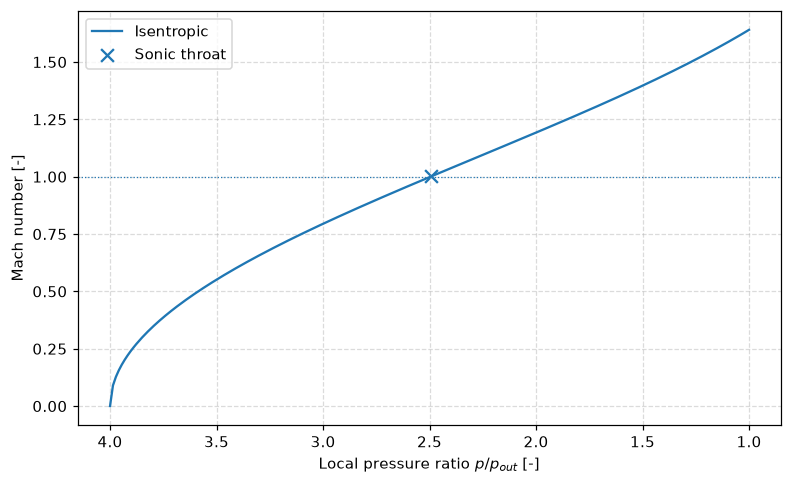

In [50]:
checkpoint("Throat pressure", float(throat_student["p_Pa"] / 1e3), (1000, 1700), "kPa")
checkpoint("Ideal nozzle exit Mach", float(nozzle_path_student.iloc[-1]["Ma_is"]), (1.20, 1.90))
plot_nozzle_expansion(nozzle_path_student, throat_index)
plt.show()

## Stator losses and the real-fluid outlet state

The detailed origin and uncertainty of the empirical correlation will be discussed, but you do not need to copy its polynomial coefficients. The backend returns the velocity coefficient $\varphi_s$. We apply it to the isentropic enthalpy conversion:

$$
h_{1}=h_0-\varphi_s^2\left(h_0-h_{1,is}\right).
$$

In [51]:
Ma_out_is = float(nozzle_path_student.iloc[-1]["Ma_is"])
phi_stator = stator_velocity_coefficient(Ma_out_is)
h_out_is = float(nozzle_path_student.iloc[-1]["h_J_kg"])

# This part is supplied because the property inversion itself is not the learning objective.
h_nozzle_out_J_kg = state_in["h_J_kg"] - phi_stator**2 * (state_in["h_J_kg"] - h_out_is)
state_nozzle_out = backend.state_PH(inputs.p_out_Pa, h_nozzle_out_J_kg, inputs.fluid)
c_nozzle_out_m_s = np.sqrt(2.0 * (state_in["h_J_kg"] - h_nozzle_out_J_kg))
Ma_nozzle_out = c_nozzle_out_m_s / state_nozzle_out["a_m_s"]

pd.Series({
    "phi_stator": phi_stator,
    "Ma_out_is": Ma_out_is,
    "Ma_out_loss_adjusted": Ma_nozzle_out,
    "rho_nozzle_out_kg_m3": state_nozzle_out["rho_kg_m3"],
})

phi_stator               0.917810
Ma_out_is                1.640316
Ma_out_loss_adjusted     1.489838
rho_nozzle_out_kg_m3    23.002133
dtype: float64

<div style="padding:0.8rem 1rem;background:#fff3e0;border-left:6px solid #ef6c00;border-radius:5px">
<b>YOUR TASK B2 — throat and outlet areas</b><br>
Use continuity, $A=\dot{m}/(\rho c)$, at the sonic throat and at the loss-adjusted outlet.
</div>

In [52]:
# SOLUTION B2 — continuity at throat and nozzle outlet
A_throat_m2 = inputs.m_dot_kg_s / (
    throat_student["rho_kg_m3"] * throat_student["c_is_m_s"]
)
A_outlet_m2 = inputs.m_dot_kg_s / (
    state_nozzle_out["rho_kg_m3"] * c_nozzle_out_m_s
)
area_ratio = A_outlet_m2 / A_throat_m2

pd.Series({
    "A_throat_mm2": A_throat_m2 * 1e6,
    "A_outlet_mm2": A_outlet_m2 * 1e6,
    "A_outlet_over_A_throat": area_ratio,
})


A_throat_mm2              604.098075
A_outlet_mm2              991.230501
A_outlet_over_A_throat      1.640844
dtype: float64

In [53]:
checkpoint("Total throat area", A_throat_m2 * 1e6, (200, 1000), "mm²")
checkpoint("Loss-adjusted total outlet area", A_outlet_m2 * 1e6, (600, 1050), "mm²")

True

## Partial admission and first-order blade height

The stator exit velocity is resolved into axial and tangential components:

$$
c_{1a}=c_1\sin\alpha_1,\qquad c_{1u}=c_1\cos\alpha_1.
$$

The active annulus flow area is approximately $e\pi D_{mid}h$, giving

$$
h_s=\frac{\dot m}{\rho_1c_{1a}e\pi D_{mid}}.
$$

The integer number of nozzles changes the effective admission fraction slightly. The pitch calculation is prepared; you will complete the velocity components and height.

In [54]:
alpha_1_rad = np.radians(inputs.alpha_stator_deg)
chord_stator_ax_m = 1.25 * inputs.rotor_chord_m
stator_pitch_m = chord_stator_ax_m / inputs.stator_solidity
circumference_m = np.pi * inputs.D_mid_m
no_nozzles = max(1, round(inputs.partial_admission * circumference_m / stator_pitch_m))
partial_admission_eff = no_nozzles * stator_pitch_m / circumference_m

# SOLUTION B3 — velocity components and first-order blade height
c1a_m_s = c_nozzle_out_m_s * np.sin(alpha_1_rad)
c1u_m_s = c_nozzle_out_m_s * np.cos(alpha_1_rad)

h_nozzle_m = inputs.m_dot_kg_s / (
    state_nozzle_out["rho_kg_m3"]
    * c1a_m_s
    * partial_admission_eff
    * np.pi
    * inputs.D_mid_m
)

# Small radial clearance/height allowance used by the teaching model.
h_rotor_m = h_nozzle_m + 0.0003

pd.Series({
    "c1a_m_s": c1a_m_s,
    "c1u_m_s": c1u_m_s,
    "no_nozzles": no_nozzles,
    "partial_admission_eff": partial_admission_eff,
    "h_nozzle_mm": h_nozzle_m * 1e3,
    "h_rotor_mm": h_rotor_m * 1e3,
})


c1a_m_s                   43.938841
c1u_m_s                  215.966304
no_nozzles                24.000000
partial_admission_eff      0.994718
h_nozzle_mm                7.954984
h_rotor_mm                 8.254984
dtype: float64

In [55]:
checkpoint("Nozzle height", h_nozzle_m * 1e3, (5, 20), "mm")

True

> **STOP — joint discussion.** Why is the blade height based on the axial component $c_{1a}$, while the throat/outlet slot areas above were defined perpendicular to the local nozzle velocity?

<div style="padding:0.8rem 1rem;background:#e8f5e9;border-left:6px solid #2e7d32;border-radius:5px">
<b>TEACHER NOTE — area orientation</b><br>
The throat and nozzle-exit slot areas are defined normal to the local nozzle velocity, so continuity uses the local speed magnitude. The annulus blade height is based on flow crossing an axial plane, therefore the relevant component is $c_{1a}$.
</div>


---
# Block C — Rotor velocity triangles and Euler work

At rotor inlet:

$$
w_{1a}=c_{1a},\qquad w_{1u}=c_{1u}-U.
$$

The rotor relative outlet speed is reduced by the prepared empirical coefficient $\varphi_r$ and a partial-admission filling/emptying coefficient $K_s$. The rotor metal exit angle is represented internally as $\beta_2=180^\circ-\beta_{2,input}$.

<div style="padding:0.8rem 1rem;background:#fff3e0;border-left:6px solid #ef6c00;border-radius:5px">
<b>YOUR TASK C1 — rotor inlet triangle</b><br>
Transform the stator exit velocity into the relative frame and calculate the relative flow angle.
</div>

In [56]:
# SOLUTION C1 — rotor inlet velocity triangle
w1a_m_s = c1a_m_s
w1u_m_s = c1u_m_s - U_m_s
w1_m_s = np.sqrt(w1a_m_s**2 + w1u_m_s**2)
beta1_flow_deg = np.degrees(np.arctan2(w1a_m_s, w1u_m_s))
Ma1_rel = w1_m_s / state_nozzle_out["a_m_s"]

pd.Series({
    "w1_m_s": w1_m_s,
    "beta1_flow_deg": beta1_flow_deg,
    "beta1_metal_deg": inputs.beta_rotor_in_deg,
    "incidence_proxy_deg": beta1_flow_deg - inputs.beta_rotor_in_deg,
    "Ma1_rel": Ma1_rel,
})


w1_m_s                 119.609433
beta1_flow_deg          21.552440
beta1_metal_deg         27.000000
incidence_proxy_deg     -5.447560
Ma1_rel                  0.808558
dtype: float64

The empirical rotor coefficient is supplied. You still implement the velocity transformation back to the absolute frame.

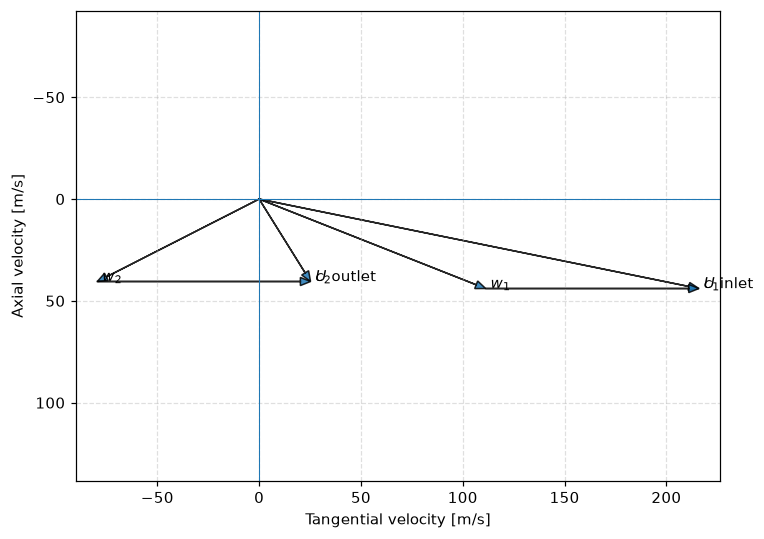

In [57]:
beta2_geometry_deg = 180.0 - inputs.beta_rotor_out_deg
theta_deg = beta2_geometry_deg - inputs.beta_rotor_in_deg
phi_rotor_base, phi_rotor = rotor_velocity_coefficient(
    theta_deg, Ma1_rel, h_rotor_m, inputs.rotor_chord_m
)

rotor_pitch_nominal_m = inputs.rotor_chord_m / inputs.rotor_solidity
no_rotor_blades = max(3, round(circumference_m / rotor_pitch_nominal_m))
rotor_pitch_m = circumference_m / no_rotor_blades
active_arc_m = partial_admission_eff * circumference_m
Ks = sector_filling_coefficient(rotor_pitch_m, active_arc_m)

# SOLUTION C2 — relative outlet and transformation back to absolute frame
beta2_geometry_rad = np.radians(beta2_geometry_deg)
w2_signed_m_s = -w1_m_s * phi_rotor * Ks
w2a_m_s = w2_signed_m_s * (-np.sin(beta2_geometry_rad))
w2u_m_s = w2_signed_m_s * (-np.cos(beta2_geometry_rad))
c2a_m_s = w2a_m_s
c2u_m_s = w2u_m_s + U_m_s
c2_m_s = np.sqrt(c2a_m_s**2 + c2u_m_s**2)

student_velocities = {
    "U_m_s": U_m_s,
    "c1u_m_s": c1u_m_s,
    "c1a_m_s": c1a_m_s,
    "w1u_m_s": w1u_m_s,
    "w1a_m_s": w1a_m_s,
    "w2u_m_s": w2u_m_s,
    "w2a_m_s": w2a_m_s,
    "c2u_m_s": c2u_m_s,
    "c2a_m_s": c2a_m_s,
}
plot_velocity_triangles(student_velocities)
plt.show()


In [58]:
checkpoint("Relative inlet Mach", Ma1_rel, (0.6, 1.25))
checkpoint("Rotor exit tangential velocity c2u", c2u_m_s, (-45, 45), "m/s")

True

### Engineering interpretation

1. Why does non-zero $c_{2u}$ represent kinetic energy not fully converted to shaft work?
2. Is a small negative $c_{2u}$ necessarily unacceptable if a downstream machine is connected through a sufficiently long duct?
3. Why can changing only the rotor exit metal angle have a surprisingly small effect on $c_{2u}$?

<div style="padding:0.8rem 1rem;background:#e8f5e9;border-left:6px solid #2e7d32;border-radius:5px">
<b>TEACHER NOTE — engineering interpretation</b><br>
<b>1.</b> Euler work depends on the change in tangential momentum. Residual $c_{2u}$ means that swirl remains at rotor exit instead of being converted into shaft work.<br><b>2.</b> A small negative $c_{2u}$ is not automatically unacceptable, but the remaining kinetic energy will normally be dissipated downstream unless deliberately recovered.<br><b>3.</b> Changing the exit metal angle changes only the projection of the relative exit velocity; the magnitude of $w_2$, the blade speed $U$ and the loss correlation also influence $c_{2u}$.
</div>


---
# Block D — Power, losses, efficiency, and geometry

Euler's turbine equation gives the aerodynamic power:

$$
P_{aero}=\dot m U(c_{1u}-c_{2u}).
$$

The teaching model then subtracts disk-friction and partial-admission loss estimates. These empirical correlations are provided because their calibration and uncertainty are a separate research topic.

In [59]:
# The rotor static outlet state is needed by the empirical power-loss terms.
dh_rotor_static_J_kg = 0.5 * (w1_m_s**2 - w2_signed_m_s**2)
h_rotor_out_J_kg = h_nozzle_out_J_kg + dh_rotor_static_J_kg
state_rotor_out = backend.state_PH(inputs.p_out_Pa, h_rotor_out_J_kg, inputs.fluid)

# SOLUTION D1 — Euler work and mechanical losses
P_aero_W = inputs.m_dot_kg_s * U_m_s * (c1u_m_s - c2u_m_s)

P_fric_W = disk_friction_loss_W(
    rho2_kg_m3=state_rotor_out["rho_kg_m3"],
    n_rpm=inputs.n_rpm,
    D_mid_m=inputs.D_mid_m,
)

P_pa = partial_admission_losses_W(
    partial_admission=partial_admission_eff,
    rho2_kg_m3=state_rotor_out["rho_kg_m3"],
    n_rpm=inputs.n_rpm,
    D_mid_m=inputs.D_mid_m,
    h_rotor_m=h_rotor_m,
    U_m_s=U_m_s,
)

# The helper returns the selected partial-admission loss together with
# the underlying correlation components.
P_partial_admission_W = P_pa["selected_W"]

P_mech_W = P_aero_W - P_fric_W - P_partial_admission_W
eta_turb = P_mech_W / (inputs.m_dot_kg_s * dh_is_J_kg)

pd.Series({
    "P_aero_kW": P_aero_W / 1e3,
    "P_fric_kW": P_fric_W / 1e3,
    "P_partial_admission_kW": P_partial_admission_W / 1e3,
    "P_mech_kW": P_mech_W / 1e3,
    "eta_turb": eta_turb,
})


P_aero_kW                 100.360585
P_fric_kW                   0.336660
P_partial_admission_kW      0.027889
P_mech_kW                  99.996036
eta_turb                    0.690234
dtype: float64

In [60]:
checkpoint("Aerodynamic power", P_aero_W / 1e3, (85, 110), "kW")
checkpoint("Mechanical power", P_mech_W / 1e3, (75, 100), "kW")
checkpoint("Turbine efficiency", eta_turb, (0.45, 0.75))

True

<div style="padding:0.8rem 1rem;background:#fff3e0;border-left:6px solid #ef6c00;border-radius:5px">
<b>YOUR TASK D2 — geometric summary</b><br>
Complete the hub/tip diameters and the per-nozzle throat/outlet widths.
</div>

In [61]:
# SOLUTION D2 — basic annulus and nozzle geometry
D_hub_m = inputs.D_mid_m - h_rotor_m
D_tip_m = inputs.D_mid_m + h_rotor_m
b_nozzle_throat_m = A_throat_m2 / (no_nozzles * h_nozzle_m)
b_nozzle_out_m = A_outlet_m2 / (no_nozzles * h_nozzle_m)

student_summary = pd.DataFrame([
    ("Pressure ratio", pressure_ratio, "-"),
    ("Ideal nozzle exit Mach", Ma_out_is, "-"),
    ("Real nozzle exit Mach", Ma_nozzle_out, "-"),
    ("U/c_is", U_over_cis, "-"),
    ("Mechanical power", P_mech_W / 1e3, "kW"),
    ("Turbine efficiency", eta_turb, "-"),
    ("Nozzle count", no_nozzles, "-"),
    ("Rotor blade count", no_rotor_blades, "-"),
    ("Rotor height", h_rotor_m * 1e3, "mm"),
    ("Hub diameter", D_hub_m * 1e3, "mm"),
    ("Tip diameter", D_tip_m * 1e3, "mm"),
    ("Single-nozzle throat width", b_nozzle_throat_m * 1e3, "mm"),
    ("Single-nozzle outlet width", b_nozzle_out_m * 1e3, "mm"),
], columns=["Quantity", "Value", "Unit"])
student_summary


,Quantity,Value,Unit
0,Pressure ratio,4.000000,-
1,Ideal nozzle exit Mach,1.640316,-
2,Real nozzle exit Mach,1.489838,-
3,U/c_is,0.436102,-
4,Mechanical power,99.996036,kW
5,Turbine efficiency,0.690234,-
6,Nozzle count,24.000000,-
7,Rotor blade count,25.000000,-
8,Rotor height,8.254984,mm
9,Hub diameter,191.745016,mm


## Compare your reconstruction with the complete reference model

The reference model uses the same equations but also contains robust state handling and a consistent data structure for the interactive and off-design parts.

In [76]:
reference_design = design_stage(inputs, backend=backend)
compare_with_reference("Efficiency", eta_turb, reference_design.performance["eta_turb"], unit="-")
compare_with_reference("Mechanical power", P_mech_W, reference_design.performance["P_mech_W"], unit="W")
compare_with_reference("Throat area", A_throat_m2, reference_design.geometry["A_throat_m2"], unit="m²")
reference_design.summary()

,Quantity,Value,Unit
0,Fluid,R1233zd(E),-
1,Pressure ratio,4.0,-
2,Isentropic enthalpy drop,28.830396,kJ/kg
3,Isentropic velocity,240.126616,m/s
4,Ideal nozzle exit Mach,1.640316,-
5,Loss-adjusted nozzle exit Mach,1.489838,-
6,Blade-speed ratio U/c_is,0.436102,-
7,Aerodynamic power,100.047235,kW
8,Mechanical power,99.682768,kW
9,Turbine efficiency,0.688071,-


In [77]:
design_file = reference_design.export_json(OUTPUT_DIR / "design_point.json")
print(f"Saved frozen design point to {design_file}")

Saved frozen design point to C:\GitHub\KCORC_summer_school\outputs\design_point.json


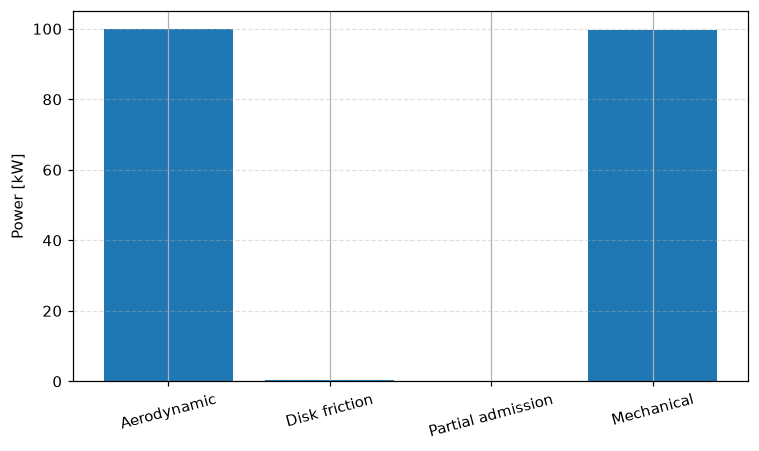

In [78]:
plot_loss_breakdown(reference_design)
plt.show()

## Design playground

Change **one parameter only**, predict the direction of change before moving the slider, and then explain the result.

Suggested group cases:

- lower rotational speed;
- lower mean diameter;
- higher pressure ratio;
- higher partial admission;
- different stator angle;
- different working fluid.

In [79]:
design_explorer(inputs)

---
# Block E — Reduced off-design characteristic for TESPy

<div style="padding:0.8rem 1rem;background:#eef4ff;border-left:6px solid #1565c0;border-radius:5px">
<b>No student coding task in this block.</b><br>
Run the cells and inspect the result. This is the final handoff from the turbine model to Francesco's TESPy workshop.
</div>

The turbine geometry designed above is now **frozen**. For cycle-level modelling we deliberately reduce the full turbine behaviour to a one-dimensional characteristic along the optimum-speed line.

For every pressure ratio

$$
\Pi = \frac{p_{\mathrm{in}}}{p_{\mathrm{out}}},
$$

the model evaluates a range of shaft speeds and selects the speed giving the highest turbine efficiency,

$$
n_{\mathrm{opt}} = n_{\mathrm{opt}}(\Pi).
$$

The corresponding reduced efficiency characteristic is

$$
\eta_{\mathrm{is,ts,opt}}
=
\eta_{\mathrm{is,ts}}
\left(
\Pi,n_{\mathrm{opt}}
\right).
$$

For a fixed pressure ratio, mass flow and isentropic enthalpy drop are the same for all tested shaft speeds. Therefore maximizing mechanical power and maximizing total-to-static efficiency are equivalent here.

The cycle model will use only $\eta_{\mathrm{is,ts}}(\Pi)$. The optimum rpm is exported as an **informative post-processing result**, not as an additional TESPy degree of freedom.

## Mass flow: fixed turbine swallowing capacity

The mass flow is **not prescribed independently** in this reduced turbine model. It follows from the fixed nozzle geometry.

When the stator is choked,

$$
\dot{m}
=
A^* \rho^* c^*,
$$

where $A^*$ is the frozen total sonic-throat area and the sonic state is evaluated from the current turbine inlet state.

The current teaching backend implicitly uses a discharge coefficient of one. A calibrated $C_d$ can be added later without changing the structure of the model.

For the characteristic below we use a sliding-pressure path:

- turbine outlet pressure remains at the design value;
- inlet pressure changes with pressure ratio;
- inlet superheat is kept at its design value where a saturation state exists;
- only **choked and otherwise valid** turbine points are retained.

In [80]:
# Freeze the hardware designed in Blocks A-D.
geometry = freeze_geometry(reference_design, backend=backend)

# Pressure-ratio range for the reduced characteristic.
# Keep the upper inlet pressure below the critical region where possible.
p_critical_Pa = backend.critical_pressure(geometry.fluid)

PR_min = max(1.6, 0.45 * geometry.pressure_ratio_design)
PR_max = min(
    1.60 * geometry.pressure_ratio_design,
    0.92 * p_critical_Pa / geometry.p_out_design_Pa,
)

PR_values = np.linspace(PR_min, PR_max, 32)

# Wide speed search around the design point.
# Speed is only an internal optimization variable in this block.
n_search_values = np.linspace(
    0.35 * geometry.n_design_rpm,
    2.00 * geometry.n_design_rpm,
    72,
)

print(f"Design pressure ratio: {geometry.pressure_ratio_design:.3f}")
print(f"Pressure-ratio sweep:  {PR_min:.3f} ... {PR_max:.3f}")
print(
    f"Speed search:          {n_search_values[0]:.0f} ... "
    f"{n_search_values[-1]:.0f} rpm"
)

Design pressure ratio: 4.000
Pressure-ratio sweep:  1.800 ... 6.400
Speed search:          3500 ... 20000 rpm


In [81]:
records = []
skipped = []

for PR in PR_values:
    p_in_Pa = PR * geometry.p_out_design_Pa

    # Constant-design-superheat sliding-pressure path.
    T_in_K = inlet_temperature_for_pressure(
        geometry,
        p_in_Pa,
        backend=backend,
    )

    # Stator solution: fixed throat/outlet areas determine swallowing capacity.
    stator = evaluate_stator_offdesign(
        geometry,
        p_in_Pa,
        T_in_K,
        geometry.p_out_design_Pa,
        backend=backend,
    )

    # This reduced characteristic is intended for the supersonic/choked regime.
    if not stator["valid_stator"] or not stator["choked"]:
        skipped.append((PR, "stator not choked/valid"))
        continue

    candidates = []

    for n_rpm in n_search_values:
        point = evaluate_rotor_offdesign(
            geometry,
            stator,
            n_rpm,
            backend=backend,
        )

        if point["valid"]:
            candidates.append(point)

    if not candidates:
        skipped.append((PR, "no valid rotor speed"))
        continue

    # At fixed PR the thermodynamic denominator m_dot * dh_is is constant,
    # so maximizing eta_turb is equivalent to maximizing P_mech.
    optimum = max(candidates, key=lambda point: point["eta_turb"])

    records.append({
        "pressure_ratio": float(PR),
        "p_in_Pa": float(p_in_Pa),
        "T_in_K": float(T_in_K),
        "p_out_Pa": float(geometry.p_out_design_Pa),
        "m_dot_kg_s": float(stator["m_dot_kg_s"]),
        "eta_is_ts": float(optimum["eta_turb"]),
        "P_mech_W": float(optimum["P_mech_W"]),
        "n_opt_rpm": float(optimum["n_rpm"]),
        "U_over_cis_opt": float(optimum["U_over_cis"]),
        "Ma_nozzle_out": float(stator["Ma_nozzle_out"]),
        "area_mismatch_rel": float(stator["area_mismatch_rel"]),
        "choked": bool(stator["choked"]),
    })

reduced_map = pd.DataFrame.from_records(records)

if reduced_map.empty:
    raise RuntimeError(
        "No valid choked off-design points were found. "
        "Check the pressure-ratio and speed-search ranges."
    )

print(f"Retained {len(reduced_map)} of {len(PR_values)} pressure-ratio points.")
if skipped:
    print(f"Skipped {len(skipped)} points outside the valid choked model region.")

reduced_map.head(10)

Retained 30 of 32 pressure-ratio points.
Skipped 2 points outside the valid choked model region.


,pressure_ratio,p_in_Pa,T_in_K,p_out_Pa,m_dot_kg_s,eta_is_ts,P_mech_W,n_opt_rpm,U_over_cis_opt,Ma_nozzle_out,area_mismatch_rel,choked
0,1.800000,9.000000e+05,384.061616,500000.0,2.278345,0.735417,20430.516424,7218.309859,0.484045,1.023623,-0.350037,True
1,1.948387,9.741935e+05,387.603118,500000.0,2.461967,0.728655,24853.346879,7683.098592,0.483348,1.083558,-0.335511,True
2,2.096774,1.048387e+06,390.947686,500000.0,2.645560,0.723231,29455.354876,7915.492958,0.472397,1.135314,-0.317548,True
3,2.245161,1.122581e+06,394.119096,500000.0,2.829331,0.718474,34212.795806,8380.281690,0.478327,1.180731,-0.297282,True
4,2.393548,1.196774e+06,397.136861,500000.0,3.013262,0.714519,39129.284250,8612.676056,0.473071,1.221095,-0.275430,True
5,2.541935,1.270968e+06,400.017206,500000.0,3.197342,0.711006,44184.378707,8845.070423,0.469799,1.257337,-0.252444,True
6,2.690323,1.345161e+06,402.773781,500000.0,3.381751,0.707905,49375.195718,9077.464789,0.468039,1.290156,-0.228583,True
7,2.838710,1.419355e+06,405.418187,500000.0,3.566364,0.705160,54693.421795,9309.859155,0.467462,1.320089,-0.204083,True
8,2.987097,1.493548e+06,407.960374,500000.0,3.751331,0.702708,60133.913354,9542.253521,0.467827,1.347558,-0.179058,True
9,3.135484,1.567742e+06,410.408942,500000.0,3.936390,0.700485,65684.311235,9774.647887,0.468956,1.372900,-0.153673,True


## Reduced characteristic

The first plot is the quantity needed directly by the cycle model:

$$
\eta_{\mathrm{is,ts}} = f(\Pi).
$$

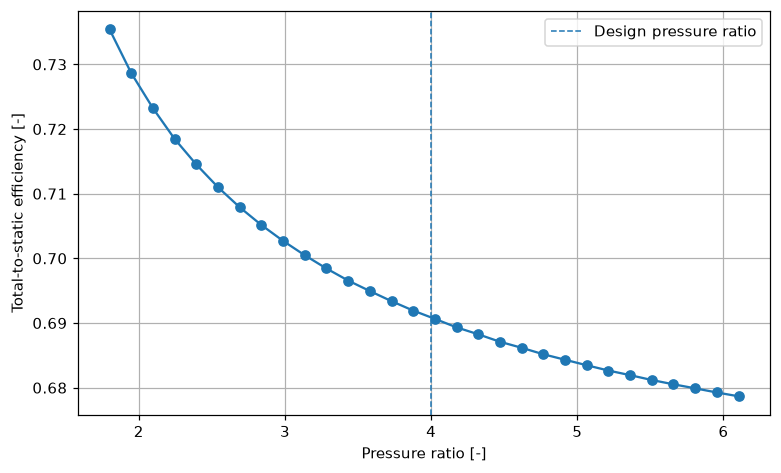

In [82]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(
    reduced_map["pressure_ratio"],
    reduced_map["eta_is_ts"],
    marker="o",
)
ax.axvline(
    geometry.pressure_ratio_design,
    linestyle="--",
    linewidth=1.0,
    label="Design pressure ratio",
)
ax.set_xlabel("Pressure ratio [-]")
ax.set_ylabel("Total-to-static efficiency [-]")
ax.legend()
fig.tight_layout()
plt.show()

The optimum rotational speed is retained only as an informative result. It represents ideal variable-speed operation of the same fixed turbine.

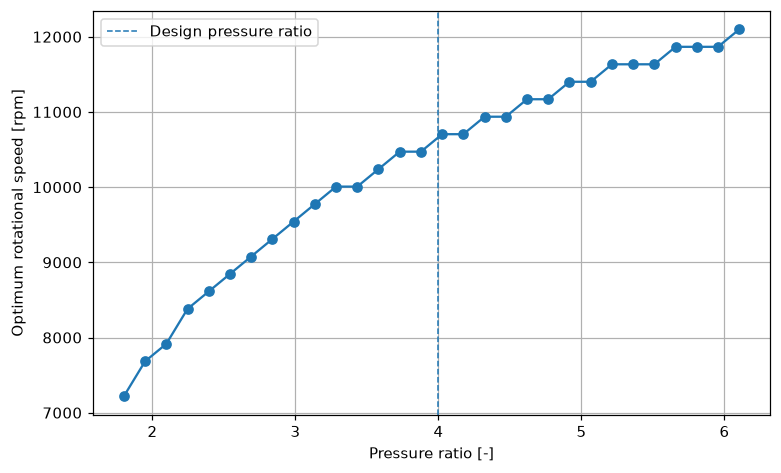

In [69]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(
    reduced_map["pressure_ratio"],
    reduced_map["n_opt_rpm"],
    marker="o",
)
ax.axvline(
    geometry.pressure_ratio_design,
    linestyle="--",
    linewidth=1.0,
    label="Design pressure ratio",
)
ax.set_xlabel("Pressure ratio [-]")
ax.set_ylabel("Optimum rotational speed [rpm]")
ax.legend()
fig.tight_layout()
plt.show()

Finally, the mass-flow curve shows the **swallowing capacity of the frozen turbine geometry** along the selected sliding-pressure path.

Because $p_{\mathrm{out}}$ is fixed here, increasing $\Pi$ means increasing $p_{\mathrm{in}}$. Therefore the choked mass flow can still rise with pressure ratio. Choking makes the mass flow insensitive to a further reduction of downstream pressure at a fixed inlet state; it does **not** make mass flow independent of inlet pressure.

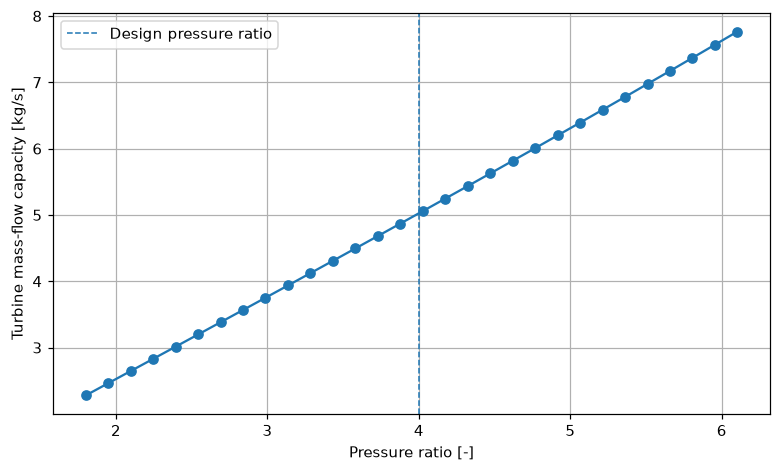

In [70]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(
    reduced_map["pressure_ratio"],
    reduced_map["m_dot_kg_s"],
    marker="o",
)
ax.axvline(
    geometry.pressure_ratio_design,
    linestyle="--",
    linewidth=1.0,
    label="Design pressure ratio",
)
ax.set_xlabel("Pressure ratio [-]")
ax.set_ylabel("Turbine mass-flow capacity [kg/s]")
ax.legend()
fig.tight_layout()
plt.show()

## Export for the TESPy workshop

The JSON handoff contains:

- the one-dimensional efficiency characteristic $\eta_{\mathrm{is,ts}}(\Pi)$;
- optimum rpm as an informative result;
- mass-flow capacity along the selected sliding-pressure path;
- the frozen throat area, so the turbine swallowing relation can also be evaluated directly from the inlet state in TESPy.

This keeps the cycle interface simple while preserving the physical mass-flow constraint of the turbine.

In [83]:
import json

export_data = {
    "schema": "kcorc_reduced_turbine_characteristic_v1",
    "fluid": geometry.fluid,

    "design_point": {
        "p_in_Pa": float(geometry.p_in_design_Pa),
        "T_in_K": float(geometry.T_in_design_K),
        "p_out_Pa": float(geometry.p_out_design_Pa),
        "pressure_ratio": float(geometry.pressure_ratio_design),
        "m_dot_kg_s": float(geometry.m_dot_design_kg_s),
        "n_rpm": float(geometry.n_design_rpm),
        "eta_is_ts": float(geometry.eta_design),
        "P_mech_W": float(geometry.P_mech_design_W),
    },

    "fixed_geometry": {
        "D_mid_m": float(geometry.D_mid_m),
        "A_throat_m2": float(geometry.A_throat_m2),
        "A_outlet_m2": float(geometry.A_outlet_m2),
        "h_rotor_m": float(geometry.h_rotor_m),
        "partial_admission": float(geometry.partial_admission_eff),
    },

    "mass_flow_model": {
        "type": "fixed_choked_throat",
        "equation": "m_dot = A_throat * rho_star * c_star",
        "discharge_coefficient": 1.0,
        "note": (
            "Cd=1 is implicit in the current teaching model. "
            "The sonic state is evaluated from the current turbine inlet state."
        ),
    },

    "map_assumptions": {
        "geometry": "fixed",
        "p_out_Pa": float(geometry.p_out_design_Pa),
        "inlet_path": (
            "sliding pressure with design superheat preserved where "
            "a saturation state is available"
        ),
        "speed_control": (
            "ideal variable-speed operation; maximum eta_is_ts selected "
            "at each pressure ratio"
        ),
        "validity": "only choked stator points passing the reduced-model checks",
    },

    "characteristic": {
        "pressure_ratio": reduced_map["pressure_ratio"].tolist(),
        "eta_is_ts": reduced_map["eta_is_ts"].tolist(),
        "n_opt_rpm": reduced_map["n_opt_rpm"].tolist(),
        "m_dot_kg_s": reduced_map["m_dot_kg_s"].tolist(),
        "P_mech_W": reduced_map["P_mech_W"].tolist(),
        "p_in_Pa": reduced_map["p_in_Pa"].tolist(),
        "T_in_K": reduced_map["T_in_K"].tolist(),
        "U_over_cis_opt": reduced_map["U_over_cis_opt"].tolist(),
    },
}

map_file = OUTPUT_DIR / "turbine_reduced_characteristic.json"

with map_file.open("w", encoding="utf-8") as f:
    json.dump(export_data, f, indent=2)

print(f"Saved TESPy handoff to: {map_file.resolve()}")

Saved TESPy handoff to: C:\GitHub\KCORC_summer_school\outputs\turbine_reduced_characteristic.json


> **Connection to Francesco's TESPy workshop**
>
> The cycle model can interpolate the turbine efficiency from
>
> $$
> \eta_{\mathrm{is,ts}} = f(\Pi),
> $$
>
> without solving shaft speed as an additional cycle variable. The corresponding $n_{\mathrm{opt}}$ is only reported afterwards.
>
> The turbine itself still imposes its swallowing capacity through the fixed nozzle throat. An optional **inlet control valve** can then be added in the cycle model to separate evaporator pressure from turbine inlet pressure and investigate operational control away from pure sliding-pressure operation.

## Final discussion and TESPy handoff

Be prepared to answer:

1. Which map inputs are prescribed by the cycle and which can be controlled by the turbine/generator?
2. Why is mass flow not completely independent for a fixed choked nozzle?
3. Why must off-design geometry remain frozen?
4. Which regions of the map would require CFD or experimental validation before engineering use?
5. What information does TESPy need from the map: efficiency only, or also mass-flow capacity and validity limits?

### Model limitations

- quasi-one-dimensional stator treatment;
- empirical stator, rotor, disk-friction, and partial-admission correlations;
- no explicit shock/boundary-layer interaction;
- no radial equilibrium or 3D effects;
- no leakage or detailed tip-clearance model;
- map intended for teaching and reduced-order cycle coupling, not final hardware certification.

### Suggested references

- J. Špale, PhD thesis (2024), methodology and 1D design of an axial supersonic ORC turbine stage.

<div style="padding:0.8rem 1rem;background:#e8f5e9;border-left:6px solid #2e7d32;border-radius:5px">
<b>TEACHER NOTE — final discussion</b><br>
<b>Suggested answers:</b><br>1. The cycle sets the inlet/outlet thermodynamic boundary conditions; shaft speed can be a control variable if variable-speed operation is allowed.<br>2. With a fixed choked throat, mass flow is coupled to inlet total state, fluid properties and throat area; it is therefore not an independent knob.<br>3. Off-design analysis represents the same hardware, so throat/outlet areas, diameter, blade height, angles and blade counts stay fixed.<br>4. The most uncertain regions are transitions into/out of choking, large incidence, very high Mach number, large area mismatch and any extrapolation outside the generated map.<br>5. A cycle model ideally needs efficiency, mass-flow capacity and validity limits; speed and power are useful additional outputs.
</div>
